In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from psr import estimate_delay_ami, AMIConfig
from psr import estimate_dimension_fnn, FNNConfig
from lyapunov import lyapunov_wolf_ode, AttractorODEConfig, WolfODEConfig, wolf_mle, WolfConfig
from dimension import estimate_correlation_dimension, estimate_k2_entropy, estimate_box_dimension

### Define Lorenz

In [2]:
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state

    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z

    return [dx, dy, dz]


def lorenz_jac(state, t, sigma, rho, beta):
    x, y, z = state
    return np.array([[-sigma, sigma, 0],
                      [rho - z, -1, -x],
                      [y, x, -beta]])


T = 150
dt = 0.01

t = np.arange(0, T, dt)

initial_state = [1, 1, 1]

solution = solve_ivp(lorenz, [0, T], initial_state, t_eval=t)

x = solution.y[0]


transient = int(20 / dt)   

x = x[transient:]
t = t[transient:]


### Part A

In [3]:
cfg = AMIConfig(max_lag=200)
 
tau_opt, lags, ami_vals = estimate_delay_ami(x, cfg)
print(f'Optimal time delay: {tau_opt}')

Optimal time delay: 16


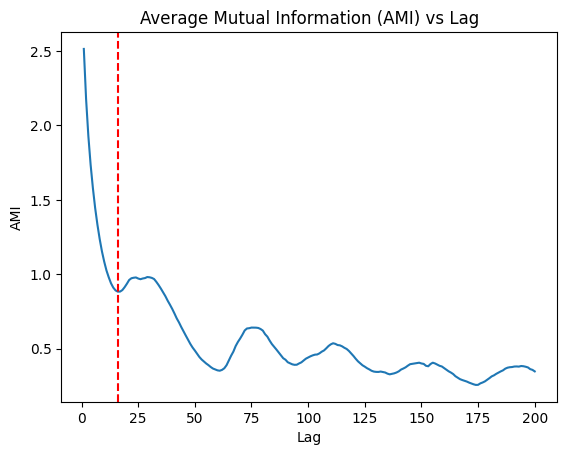

In [4]:
plt.plot(lags, ami_vals)
plt.axvline(tau_opt, color='r', ls='--')
plt.xlabel('Lag')
plt.ylabel('AMI')
plt.title('Average Mutual Information (AMI) vs Lag')
plt.show()


In [5]:
cfg = FNNConfig(theiler=100)
m_opt, dims, fnn_pct = estimate_dimension_fnn(x, tau=tau_opt, cfg=cfg)
print(f'Optimal embedding dimension: {m_opt}')

Optimal embedding dimension: 3


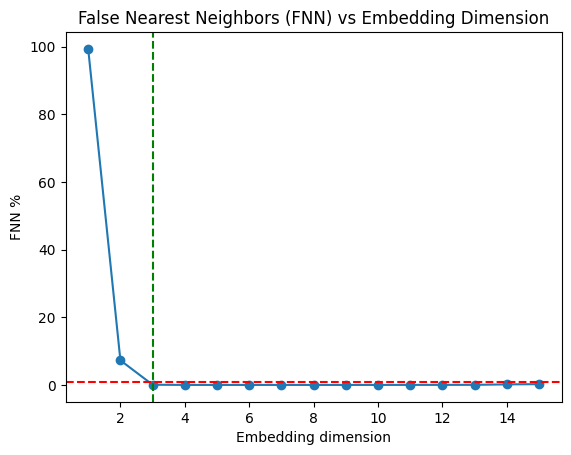

In [6]:
plt.plot(dims, fnn_pct, 'o-'); 
plt.axhline(1.0, color='r', ls='--')
plt.axvline(m_opt, color='g', ls='--')
plt.xlabel('Embedding dimension') 
plt.ylabel('FNN %')
plt.title('False Nearest Neighbors (FNN) vs Embedding Dimension')
plt.show()

### Part B

In [7]:
def lorenz_ode(state, t, sigma, rho, beta):            # state then t as AttractorODEConfig excepct
    x, y, z = state

    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z

    return np.array([dx, dy, dz])


cfg = AttractorODEConfig(
    ode=lorenz_ode, jacobian=lorenz_jac,
    x0=initial_state, params=(10, 28, 8/3),
    dt=0.01, transient_steps=1000, n_steps=30000, solver="RK45")

wolf_cfg = WolfODEConfig(ortho_steps=20, log_base = "2")
spectrum = lyapunov_wolf_ode(cfg, wolf_cfg=wolf_cfg)         
ground_truth = spectrum[0]

print(f"Lyapunov spectrum: {spectrum}")
print(f"Largest Lyapunov Exponent (ODE): {ground_truth:.4f} bits/time")


Lyapunov spectrum: [ 1.29664011e+00 -3.30677997e-03 -2.09980240e+01]
Largest Lyapunov Exponent (ODE): 1.2966 bits/time


In [8]:
cfg = WolfConfig()
 
mle, debug = wolf_mle(x, dt=dt, tau=tau_opt, m=m_opt, cfg=cfg)
print(f'Largest Lyapunov exponent: {mle:.4f} bits/time')
print(f'Segments tracked: {debug["replacements"]}')

Largest Lyapunov exponent: 1.8128 bits/time
Segments tracked: 200


### Part C

K2 Entropy = 4.0722 nats/time


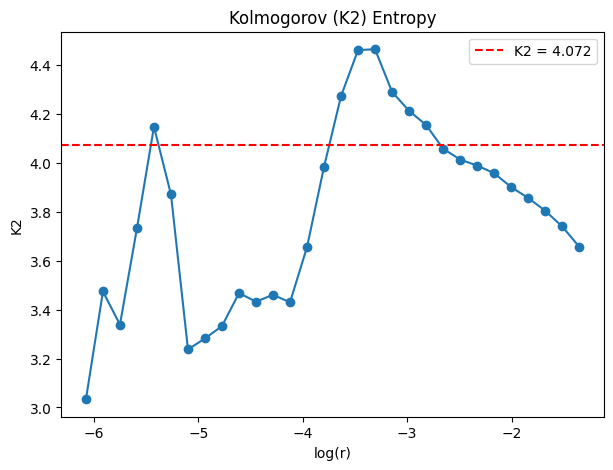

In [10]:
K2, r, K2_curve, (i0, i1) = estimate_k2_entropy(x, tau_opt, m_opt, dt)

print(f"K2 Entropy = {K2:.4f} nats/time")

plt.figure(figsize=(7,5))
plt.plot(np.log(r), K2_curve, "o-")

plt.axhline(K2, color="red", linestyle="--", label=f"K2 = {K2:.3f}")
plt.xlabel("log(r)")
plt.ylabel("K2")
plt.title("Kolmogorov (K2) Entropy")
plt.legend()
plt.show()

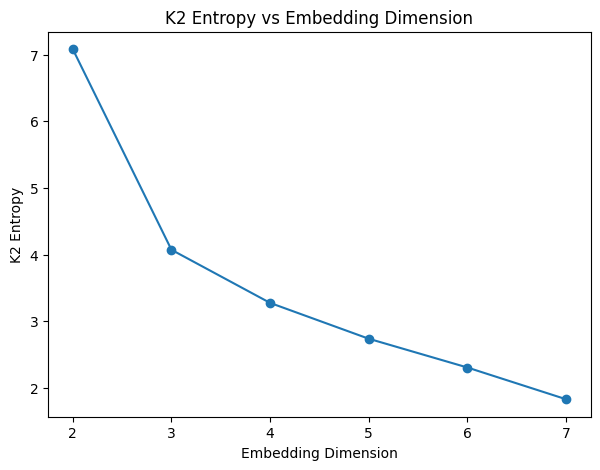

Final K2 = 1.8285331166364176


In [15]:
dims = np.arange(2, 8)

K2_values = []

for dim in dims:
    K2, r, K2_curve, (i0, i1) = estimate_k2_entropy(x, tau_opt, dim, dt)
    K2_values.append(K2)

plt.figure(figsize=(7,5))
plt.plot(dims, K2_values, "o-")
plt.xlabel("Embedding Dimension")
plt.ylabel("K2 Entropy")
plt.title("K2 Entropy vs Embedding Dimension")
plt.show()

print("Final K2 =", K2_values[-1])

### Part D

Correlation Dimension (D2) = 2.0560


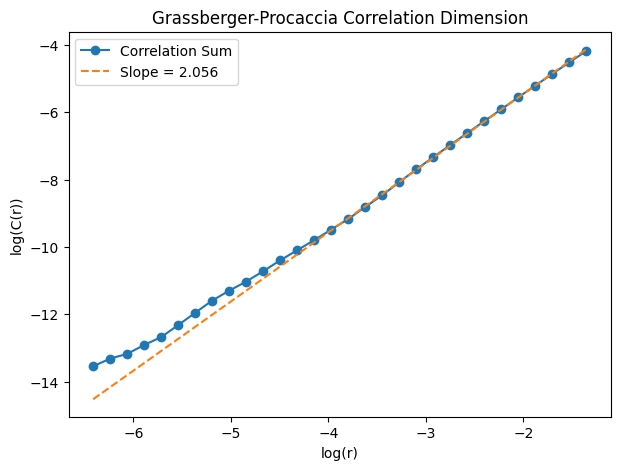

In [11]:
D2, radii, C, log_r, log_C, fit_line, (i0, i1) = estimate_correlation_dimension(x, tau_opt, m_opt)

print(f"Correlation Dimension (D2) = {D2:.4f}")

plt.figure(figsize=(7,5))
plt.plot(log_r, log_C, "o-", label="Correlation Sum")
plt.plot(log_r, fit_line, "--", label=f"Slope = {D2:.3f}")
plt.xlabel("log(r)")
plt.ylabel("log(C(r))")
plt.title("Grassberger-Procaccia Correlation Dimension")
plt.legend()
plt.show()

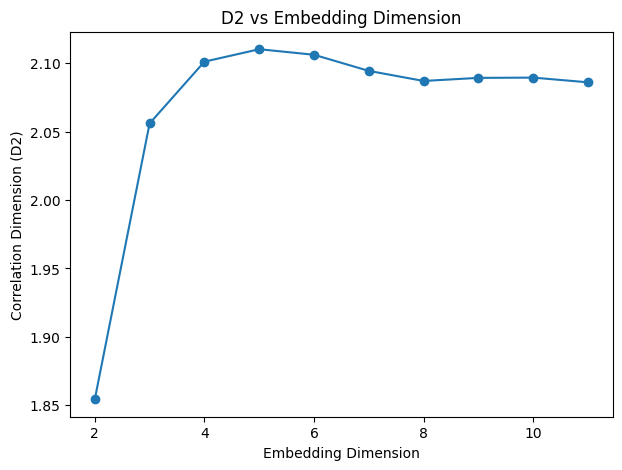

Saturated D2 = 2.0860900329581917


In [12]:
dims = np.arange(2, 12)

D2_values = []

for dim in dims:
    D2, radii, C, log_r, log_C, fit_line, (i0, i1) = estimate_correlation_dimension(x, tau_opt, dim)
    D2_values.append(D2)

plt.figure(figsize=(7,5))
plt.plot(dims, D2_values, "o-")
plt.xlabel("Embedding Dimension")
plt.ylabel("Correlation Dimension (D2)")
plt.title("D2 vs Embedding Dimension")
plt.show()

print("Saturated D2 =", D2_values[-1])

### Part E

Box Counting Dimension (D0) = 1.8024


d:\ME\Nile University Research Internship\Tasks\2 (2)\dimension.py:312: RuntimeWarning: Box counts at the smallest eps values are within 2x of the number of data points -- that region is likely finite-sample saturation, not true fractal scaling. Consider a longer simulation (more points) before pushing eps_min_ratio any smaller.
  warnings.warn(


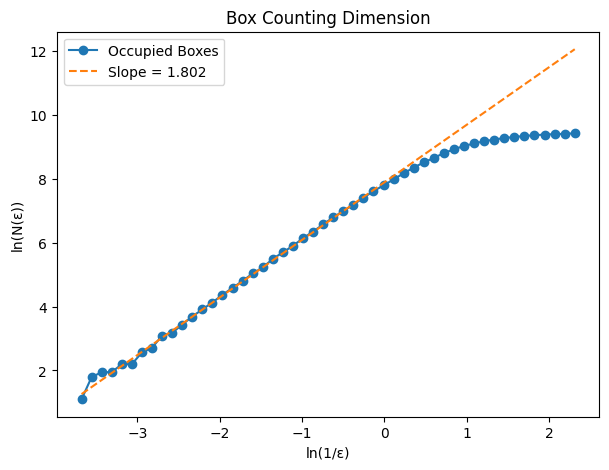

In [13]:
state_3d = solution.y.T[transient:]             

D0, eps_values, counts, log_inv_eps, log_counts, fit_line, (i0, i1) = estimate_box_dimension(state_3d)
print(f"Box Counting Dimension (D0) = {D0:.4f}")

plt.figure(figsize=(7,5))
plt.plot(log_inv_eps, log_counts, "o-", label="Occupied Boxes")
plt.plot(log_inv_eps, fit_line, "--", label=f"Slope = {D0:.3f}")
plt.xlabel("ln(1/ε)")
plt.ylabel("ln(N(ε))")
plt.title("Box Counting Dimension")
plt.legend()
plt.show()

In [14]:
print(f"Correlation Dimension (D2) : {D2:.4f}")
print(f"Box Counting Dimension (D0): {D0:.4f}")

Correlation Dimension (D2) : 2.0861
Box Counting Dimension (D0): 1.8024
